# Tutorial 410: ContextFlow CTF-H Spatially-Aware Transport via Prior-Biased Kernel

ContextFlow (Rathod et al., 2024, [arXiv:2510.02952](https://arxiv.org/abs/2510.02952)) proposes two ways to inject a spatial prior into optimal transport coupling. Tutorial 400 covered **`CTF-C`**. This tutorial implements **`CTF-H`**, which modifies the Gibbs kernel directly.

## How CTF-H works

Optimal transport finds a transport plan $\Pi$ where $\Pi_{ij}$ is the mass moved from source cell $i$ to target cell $j$.

### Standard EOT

Standard entropic OT solves:

$$\min_{\Pi \geq 0} \sum_{ij} \Pi_{ij} C_{ij} \;+\; \varepsilon \underbrace{\sum_{ij} \Pi_{ij} \log \Pi_{ij}}_{\text{entropy of }\Pi}$$

Writing this as a Lagrangian:

$$L = \sum_{ij} \Pi_{ij} C_{ij} + \varepsilon \sum_{ij} \Pi_{ij} \log \Pi_{ij} - \sum_i \lambda_i \!\left(\sum_j \Pi_{ij} - a_i\right) - \sum_j \mu_j \!\left(\sum_i \Pi_{ij} - b_j\right)$$

Derivative with respect to $\Pi_{ij}$, set to zero:

$$C_{ij} + \varepsilon(\log \Pi_{ij} + 1) - \lambda_i - \mu_j = 0$$

 Solving:

$$\Pi_{ij} = \underbrace{e^{\lambda_i/\varepsilon - 1/2}}_{u_i} \cdot \underbrace{e^{-C_{ij}/\varepsilon}}_{K_{ij}} \cdot \underbrace{e^{\mu_j/\varepsilon - 1/2}}_{v_j}$$

The **Gibbs kernel** here is  $K_{ij} = e^{-C_{ij}/\varepsilon}$. $u, v$ are found by Sinkhorn iterations. $\Pi$ knows nothing about spatial location the only signal is transcriptomic distance $C_{ij}$.

---

### CTF-H

**`CTF-H`** replaces the entropy regulariser with a KL divergence from a spatial prior $\hat{M}$:

$$\min_{\Pi \geq 0} \sum_{ij} \Pi_{ij} C_{ij} \;+\; \varepsilon \underbrace{\sum_{ij} \Pi_{ij} \log \frac{\Pi_{ij}}{\hat{M}_{ij}}}_{\text{KL divergence from }\hat{M}}$$

#### The spatial prior $\hat{M}$

$\hat{M}$ is built from the **Transitional Plausibility Matrix (TPM)**:

$$M_{ij} = \lambda\,\|ss_i - ss_j\|^2 + (1-\lambda)\,\|lr_i - lr_j\|^2$$

- $ss_i$ : Spatial Smoothness context: mean PCA expression of cell $i$'s spatial neighbours (encodes tissue niche)
- $lr_i$ : Ligand-Receptor features: LIANA co-expression profile aggregated over spatial neighbourhood
- $\lambda$ : blend between SS and LR; tunable via `CTF_H_LAMBDA`

High $M_{ij}$ = implausible transition. $\hat{M}$ row-normalises $\exp(-M)$ so plausible pairs get high weight:

$$\hat{M}_{ij} = \frac{e^{-M_{ij}}}{\sum_k e^{-M_{ik}}}$$

#### Derivation

Writing the CTF-H objective as a Lagrangian (expanding the KL term, dropping the constant $-\varepsilon$):

$$L = \sum_{ij} \Pi_{ij} C_{ij} + \varepsilon \sum_{ij} \Pi_{ij} \log \Pi_{ij} - \varepsilon \sum_{ij} \Pi_{ij} \log \hat{M}_{ij} - \sum_i \lambda_i \!\left(\sum_j \Pi_{ij} - a_i\right) - \sum_j \mu_j \!\left(\sum_i \Pi_{ij} - b_j\right)$$

Derivative with respect to $\Pi_{ij}$, set to zero:

$$C_{ij} + \varepsilon(\log \Pi_{ij} + 1) - \varepsilon \log \hat{M}_{ij} - \lambda_i - \mu_j = 0$$

Solving:

$$\Pi_{ij} = \underbrace{e^{\lambda_i/\varepsilon - 1/2}}_{u_i} \cdot \underbrace{\hat{M}_{ij} \cdot e^{-C_{ij}/\varepsilon}}_{K^{\text{CTF-H}}_{ij}} \cdot \underbrace{e^{\mu_j/\varepsilon - 1/2}}_{v_j}$$

The $\log\hat{M}_{ij}$ term in the optimality condition is what injects $\hat{M}_{ij}$ into the kernel:

$$K^{\text{CTF-H}}_{ij} = \hat{M}_{ij} \cdot e^{-C_{ij}/\varepsilon}$$

This kernel now takes into consideration the transcriptomic distance & the spatial space. 

---

**Data**: same `axolotl_processed.h5ad` as Tutorial 400 (28,757 cells, 5 developmental stages). [Refer to the paper's git repo to download and preprocess the dataset.](https://github.com/santanurathod/ContextFlow/tree/main/datasets)

In [1]:
%load_ext autoreload
%autoreload 2

## Contents

#### 1. Load Data
#### 2. Build State-Context Representation
#### 3. CTF-H Coupling — Prior-Biased Kernel
#### 4. Multi-TimePoint Flow Matching: Interpolation
#### 5. Multi-TimePoint Flow Matching: Extrapolation
#### 6. Inference & Evaluation
#### 7. Alternative: CTF-H via `cost_fn`

In [2]:
import functools
import numpy as np
import torch
import ot as pot
import scanpy as sc
import matplotlib.pyplot as plt

from sc_flow import SCFlow
from sc_flow.backends.torch._utils import to_torch_tensor

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
DATA_PATH = "400_data\\axolotl_processed.h5ad"

N_PCA = 50
N_SS = 50

CTF_H_EPS = 0.1  # entropic regularisation: controls prior vs transport tradeoff
CTF_H_NITER = 100  # Sinkhorn iterations
CTF_H_LAMBDA = 1.0  # blend within TPM: 1.0 = pure SS, 0.0 = pure LR

## 1. Load Data

Same preprocessed h5ad as Tutorial 400. It contains `X_pca` (50 PCs), `local_mean_X_pca` (SS context = mean PCA of spatial neighbours), `LR_pattern` (LIANA ligand-receptor features), and `X_umap`.

In [4]:
adata = sc.read_h5ad(DATA_PATH)
print(adata)

AnnData object with n_obs × n_vars = 28757 × 10000
    obs: 'CellID', 'Batch', 'cell_id', 'celltype', 'day'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'gene_symbol_original'
    uns: 'LR_pattern_pairs', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'LR_pattern', 'X_pca', 'X_umap', 'local_mean_X_pca', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'


c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
print("obs columns: ", list(adata.obs.columns))
print("obsm keys:   ", list(adata.obsm.keys()))

obs columns:  ['CellID', 'Batch', 'cell_id', 'celltype', 'day']
obsm keys:    ['LR_pattern', 'X_pca', 'X_umap', 'local_mean_X_pca', 'spatial']


In [6]:
adata.obs.head(5)

,CellID,Batch,cell_id,celltype,day
CELL.1,CELL.1,Stage44_telencephalon_rep2_FP200000239BL_E4,1,Immature nptxEX,Stage44
CELL.3,CELL.3,Stage44_telencephalon_rep2_FP200000239BL_E4,3,Immature nptxEX,Stage44
CELL.4,CELL.4,Stage44_telencephalon_rep2_FP200000239BL_E4,4,VLMC,Stage44
CELL.6,CELL.6,Stage44_telencephalon_rep2_FP200000239BL_E4,6,CP,Stage44
CELL.8,CELL.8,Stage44_telencephalon_rep2_FP200000239BL_E4,8,Immature nptxEX,Stage44


In [7]:
print("Stage distribution:")
print(adata.obs["day"].value_counts())

Stage distribution:
day
Juvenile    11698
Adult        8243
Stage57      4410
Stage54      2929
Stage44      1477
Name: count, dtype: int64


## 2. Build State-Context Representation

CTF-H uses the same two spatial features as CTF-C: **SS** (Spatial Smoothness) and **LR** (Ligand-Receptor). These are blended into the Transitional Plausibility Matrix via `CTF_H_LAMBDA`:

$$M_{ij} = \lambda\,\|ss_i - ss_j\|^2 + (1-\lambda)\,\|lr_i - lr_j\|^2$$

We concatenate PCA + SS + LR into a 333-dim vector `X_state_ctx`. `coupling_rep='X_state_ctx'` routes this full vector to the coupling function as `source_lin`/`target_lin`. The coupling function then splits it internally:

    source_lin[:, :N_PCA]              PCA (50-dim)           used for cost C
    source_lin[:, N_PCA:N_PCA+N_SS]    SS context (50-dim)    used for prior M_hat
    source_lin[:, N_PCA+N_SS:]         LR features (233-dim)  used for prior M_hat

This is the same pattern as Tutorial 400's `ctf_c_coupling` the coupling function owns all the splitting logic.

In [8]:
X_pca = adata.obsm["X_pca"].astype(np.float32)
ss_context = adata.obsm["local_mean_X_pca"].astype(np.float32)
lr_pattern = adata.obsm["LR_pattern"].astype(np.float32)

adata.obsm["X_state_ctx"] = np.concatenate([X_pca, ss_context, lr_pattern], axis=1)
print(f"X_pca shape:        {X_pca.shape}")
print(f"ss_context shape:   {ss_context.shape}")
print(f"lr_pattern shape:   {lr_pattern.shape}")
print(f"X_state_ctx shape:  {adata.obsm['X_state_ctx'].shape}")

X_pca shape:        (28757, 50)
ss_context shape:   (28757, 50)
lr_pattern shape:   (28757, 233)
X_state_ctx shape:  (28757, 333)


## 3. CTF-H Coupling Prior-Biased Kernel

The coupling function below implements CTF-H. POT only accepts a cost matrix. It always builds $K = e^{-M/\varepsilon}$ internally and cannot accept a custom kernel. We have $K^{\text{CTF-H}}_{ij} = \hat{M}_{ij} \cdot e^{-C_{ij}/\varepsilon}$ but no way to pass it directly.

The trick: rewrite $K^{\text{CTF-H}}$ so it looks like a standard Gibbs kernel with a modified cost:

$$K^{\text{CTF-H}}_{ij} = \hat{M}_{ij} \cdot e^{-C_{ij}/\varepsilon} = e^{\log\hat{M}_{ij}} \cdot e^{-C_{ij}/\varepsilon} = e^{-(C_{ij} - \varepsilon\log\hat{M}_{ij})/\varepsilon} = e^{-C^\text{eff}_{ij}/\varepsilon}$$

where $C^\text{eff}_{ij} = C_{ij} - \varepsilon\log\hat{M}_{ij}$. Passing $C^\text{eff}$ to POT makes it build $K^{\text{CTF-H}}$ internally. The entire CTF-H modification reduces to one line before the POT call:

```python
C_eff = C - eps * np.log(M_hat + 1e-300)   # the only CTF-H-specific line
Pi = pot.sinkhorn(a, b, C_eff, reg=eps)    # standard POT call from here on
```

In [9]:
def _sample_from_coupling(Pi: np.ndarray, n_samples: int):
    """Sample index pairs proportional to coupling matrix Pi."""
    Pi_flat = Pi.ravel()
    Pi_flat = np.clip(Pi_flat, 0, None)  # numerical safety
    total = Pi_flat.sum()
    # if total < 1e-10:
    #     Pi_flat = np.ones_like(Pi_flat)  # fallback to uniform
    #     total = Pi_flat.sum()
    Pi_flat = Pi_flat / total
    choices = np.random.choice(
        Pi.shape[0] * Pi.shape[1],
        size=n_samples,
        p=Pi_flat,
        replace=False,
    )
    src_idx, tgt_idx = np.divmod(choices, Pi.shape[1])
    return src_idx, tgt_idx

In [ ]:
def ctf_h_coupling(
    source_lin,
    target_lin,
    source_quad=None,
    target_quad=None,
    eps: float = 0.1,
    lam: float = 0.5,
    n_iter: int = 100,
    **kwargs,
):
    """CTF-H: Sinkhorn OT with prior-biased Gibbs kernel K = M_hat * exp(-C/eps)."""
    # -- 1. Split source_lin / target_lin  --------------------------------
    src_pca = source_lin[:, :N_PCA]
    src_ss = source_lin[:, N_PCA : N_PCA + N_SS]
    src_lr = source_lin[:, N_PCA + N_SS :]

    tgt_pca = target_lin[:, :N_PCA]
    tgt_ss = target_lin[:, N_PCA : N_PCA + N_SS]
    tgt_lr = target_lin[:, N_PCA + N_SS :]

    # -- 2. Cost matrix C (PCA distance, scaled for numerical stability) --
    src_t = to_torch_tensor(src_pca).float()
    tgt_t = to_torch_tensor(tgt_pca).float()
    C = torch.cdist(src_t, tgt_t) ** 2
    C = C / (C.mean() + 1e-10)

    # -- 3. Prior matrix M_hat from SS + LR context -----------------------
    src_ss_t = to_torch_tensor(src_ss).float()
    tgt_ss_t = to_torch_tensor(tgt_ss).float()

    src_lr_t = to_torch_tensor(src_lr).float()
    tgt_lr_t = to_torch_tensor(tgt_lr).float()

    # Transitional Plausibility Matrix (TPM): high = implausible transition
    SS_diss = torch.cdist(src_ss_t, tgt_ss_t) ** 2
    LR_diss = torch.cdist(src_lr_t, tgt_lr_t) ** 2

    SS_diss = SS_diss / (SS_diss.mean() + 1e-10)
    LR_diss = LR_diss / (LR_diss.mean() + 1e-10)

    M = lam * SS_diss + (1 - lam) * LR_diss

    # Row-normalise: low M[i,j] -> high M_hat[i,j] (plausible pair)
    M_hat = torch.softmax(-M, dim=1)  # (n_src, n_tgt)

    # -- 4. Effective cost: C_eff = C - eps * log(M_hat) ------------------
    C_np = C.detach().cpu().numpy().astype(np.float64)
    M_np = M_hat.detach().cpu().numpy().astype(np.float64)
    C_eff = C_np - eps * np.log(M_np + 1e-300)

    n_src, n_tgt = C_eff.shape
    a = pot.unif(n_src)
    b = pot.unif(n_tgt)

    # -- 5. POT sinkhorn in log-domain (stable at small eps) ---------------
    Pi = pot.sinkhorn(
        a,
        b,
        C_eff,
        reg=eps,
        # method="sinkhorn_log",
        numItermax=n_iter,
    )

    # -- 6. Sample index pairs from transport plan -------------------------
    return _sample_from_coupling(Pi, n_samples=n_src)

## 4. Multi-TimePoint Flow Matching: Interpolation

Before training the model, we must first understand what it is that we are doing and what is `Multi-TimePoint Flow Matching`. In a standard flow matching training, we have a `Source` and a `Target`, and we train a model to create the `velocity field` between these two distributions across n time points where at t=0 we have the `Source` distribution and at t=1 we have the `Target` distribution. When training, we take a random time-point between 0 and 1, predict the velocity and direction of the distribution.

In Multi-TimePoint Flow Matching, we consider each of the stages as intermediate timepoints. So we can imagine that at t=0 we have the `Stage44` distribution. At t=0.25 we have `Stage54`, `Stage57` at t=0.5 and so on — they all share a single velocity field. When training, we take a batch from each of these pairs and the velocity field is trained jointly.

Now coming to `Interpolation`. This is one of the 2 evaluation methods used by the authors. Here, the model is trained on all the time points except for `Juvenile`:
* Stage44 -> Stage54
* Stage54 -> Stage57
* Stage57 -> Adult

As you can see, we skip the `Juvenile` timepoint and pair `Stage57` directly with `Adult`. The logic is that since `Juvenile` is in between these 2 stages, how well can the model predict this stage?

### 4.1 Data Registration

In [11]:
# Assign normalized time embeddings to all 5 stages
STAGES_ALL = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]
STAGE_TIMES = {"Stage44": 0.00, "Stage54": 0.25, "Stage57": 0.50, "Juvenile": 0.75, "Adult": 1.00}

adata.uns["stage_emb"] = {s: np.array([t], dtype=np.float32) for s, t in STAGE_TIMES.items()}
print("Stage embeddings:", {s: round(t, 2) for s, t in STAGE_TIMES.items()})

Stage embeddings: {'Stage44': 0.0, 'Stage54': 0.25, 'Stage57': 0.5, 'Juvenile': 0.75, 'Adult': 1.0}


In [12]:
# Create the time pairs for CTF-H training (interpolation)
matched_keys_inter = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Adult",),  # Juvenile is excluded; Stage57 paired directly to Adult
}

In [13]:
SCFlow.register_adata(
    adata,
    sample_rep="X_pca",
    coupling_rep="X_state_ctx",
    conditions={"day": ["day"]},
    conditions_reps={"day": "stage_emb"},
    matched_keys=matched_keys_inter,
)

### 4.2 Model Setup & Train

In [14]:
ctf_h_fn = functools.partial(
    ctf_h_coupling,
    eps=CTF_H_EPS,
    lam=CTF_H_LAMBDA,
    n_iter=CTF_H_NITER,
)

model_inter = SCFlow(
    method_id="cfm",
    backend="torch",
    match_fn=ctf_h_fn,
    vf_decoder_mlp_kwargs={"hidden_dims": (100, 100, 100, 100)},
)
print("is_paired_setting:", model_inter.is_paired_setting)

is_paired_setting: True


In [15]:
model_inter.train(
    adata,
    callbacks=None,
    sort=True,
    n_train_steps=10_000,
    train_batch_size=256,
    optim_kwargs={"lr": 5e-4},
)

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 8/10000 [00:00<06:36, 25.22it/s]c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\ot\bregman\_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
| loss:3.9305 | step:9999: 100%|██████████| 10000/10000 [08:39<00:00, 19.27it/s]


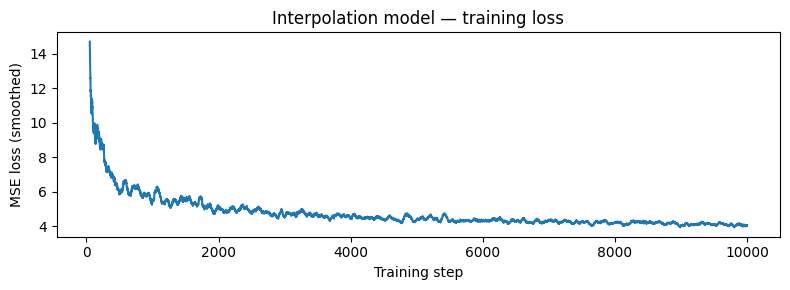

In [16]:
logs_inter = model_inter.trainer.get_train_logs_df()
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(logs_inter["loss"].rolling(50).mean(), lw=1.5)
ax.set_xlabel("Training step")
ax.set_ylabel("MSE loss (smoothed)")
ax.set_title("Interpolation model — training loss")
plt.tight_layout()
plt.show()

## 5. Multi-TimePoint Flow Matching: Extrapolation

`Extrapolation` is the other of the 2 evaluation methods used by the authors. Here, the model is trained on all the time points except for `Adult`:
* Stage44 -> Stage54
* Stage54 -> Stage57
* Stage57 -> Juvenile

The logic is that the `Adult` timepoint is completely out of the timepoints used in training. So how well can the model extrapolate from what it has learned and predict?

### 5.1 Data Registration

Sampel the same data with my custom coupling and theircoupling nd check the results and check if they are the same. (Just copy their code)

In [17]:
# Assign normalized time embeddings to all 5 stages
STAGES_ALL = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]
STAGE_TIMES = {"Stage44": 0.00, "Stage54": 0.25, "Stage57": 0.50, "Juvenile": 0.75, "Adult": 1.00}

adata.uns["stage_emb"] = {s: np.array([t], dtype=np.float32) for s, t in STAGE_TIMES.items()}
print("Stage embeddings:", {s: round(t, 2) for s, t in STAGE_TIMES.items()})

Stage embeddings: {'Stage44': 0.0, 'Stage54': 0.25, 'Stage57': 0.5, 'Juvenile': 0.75, 'Adult': 1.0}


In [18]:
# Create the time pairs for CTF-H training (extrapolation)
matched_keys_extra = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Juvenile",),  # Adult is excluded
}

In [19]:
SCFlow.register_adata(
    adata,
    sample_rep="X_pca",
    coupling_rep="X_state_ctx",
    conditions={"day": ["day"]},
    conditions_reps={"day": "stage_emb"},
    matched_keys=matched_keys_extra,
)

### 5.2 Model Setup & Training

In [20]:
model_extra = SCFlow(
    method_id="cfm",
    backend="torch",
    match_fn=ctf_h_fn,
    vf_decoder_mlp_kwargs={"hidden_dims": (100, 100, 100, 100)},
)
print("is_paired_setting:", model_extra.is_paired_setting)

is_paired_setting: True


In [21]:
model_extra.train(
    adata,
    callbacks=None,
    sort=True,
    n_train_steps=10_000,
    train_batch_size=256,
    optim_kwargs={"lr": 5e-4},
)

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
  0%|          | 1/10000 [00:00<24:27,  6.81it/s]c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\ot\bregman\_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
| loss:3.5547 | step:9999: 100%|██████████| 10000/10000 [05:31<00:00, 30.18it/s]


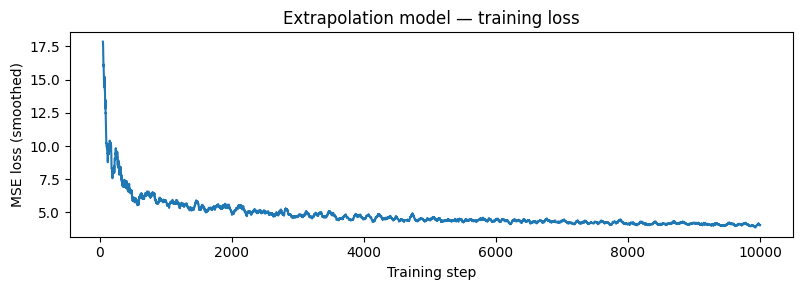

In [22]:
logs_extra = model_extra.trainer.get_train_logs_df()
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(logs_extra["loss"].rolling(50).mean(), lw=1.5)
ax.set_xlabel("Training step")
ax.set_ylabel("MSE loss (smoothed)")
ax.set_title("Extrapolation model — training loss")
plt.tight_layout()
plt.show()

## 6. Inference & Evaluation

In [ ]:
def plot_transition(ax, adata, src_stage, tgt_stage, X_pred, title=None):
    """Scatter source, predicted, and true target cells in PCA space."""
    X_pca_all = adata.obsm["X_pca"]
    src_mask = adata.obs["day"].values == src_stage
    tgt_mask = adata.obs["day"].values == tgt_stage

    ax.scatter(X_pca_all[src_mask, 0], X_pca_all[src_mask, 1], s=2, alpha=0.15, color="steelblue", label=src_stage)
    ax.scatter(X_pred[:, 0], X_pred[:, 1], s=5, alpha=0.7, color="tomato", label="Predicted")
    ax.scatter(X_pca_all[tgt_mask, 0], X_pca_all[tgt_mask, 1], s=5, alpha=0.5, color="seagreen", label=tgt_stage)
    ax.set_title(title or f"{src_stage} → {tgt_stage}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.tick_params(left=False, bottom=False)
    ax.legend(loc="upper right", markerscale=2, frameon=False)

In [ ]:
def plot_pcas(ax, adata, src_stage, tgt_stage, title=None):
    """Scatter source and true target cells in PCA space without predictions."""
    X_pca_all = adata.obsm["X_pca"]
    src_mask = adata.obs["day"].values == src_stage
    tgt_mask = adata.obs["day"].values == tgt_stage

    ax.scatter(X_pca_all[src_mask, 0], X_pca_all[src_mask, 1], s=2, alpha=1, color="steelblue", label=src_stage)
    ax.scatter(X_pca_all[tgt_mask, 0], X_pca_all[tgt_mask, 1], s=5, alpha=0.5, color="seagreen", label=tgt_stage)
    ax.set_title(title or f"{src_stage} → {tgt_stage}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.tick_params(left=False, bottom=False)
    ax.legend(loc="upper right", markerscale=2, frameon=False)

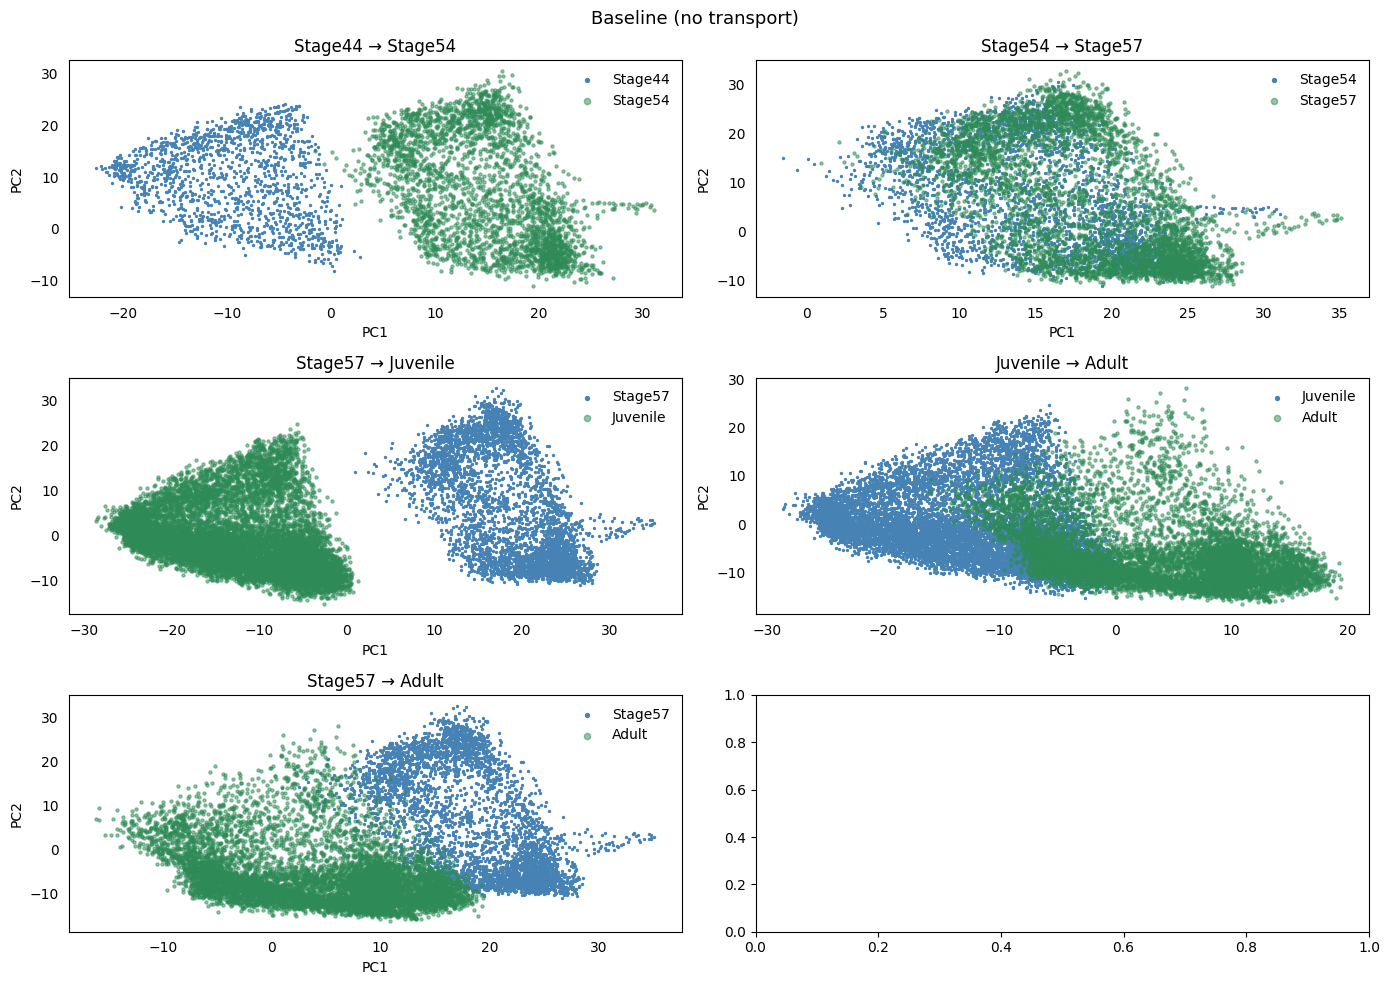

In [25]:
transitions = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
    ("Stage57", "Adult"),  # direct transition skipping Juvenile
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, (src, tgt) in zip(axes.flat, transitions, strict=False):
    plot_pcas(ax, adata, src, tgt)

plt.suptitle("Baseline (no transport)", fontsize=13)
plt.tight_layout()
plt.show()

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.94s/it]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str

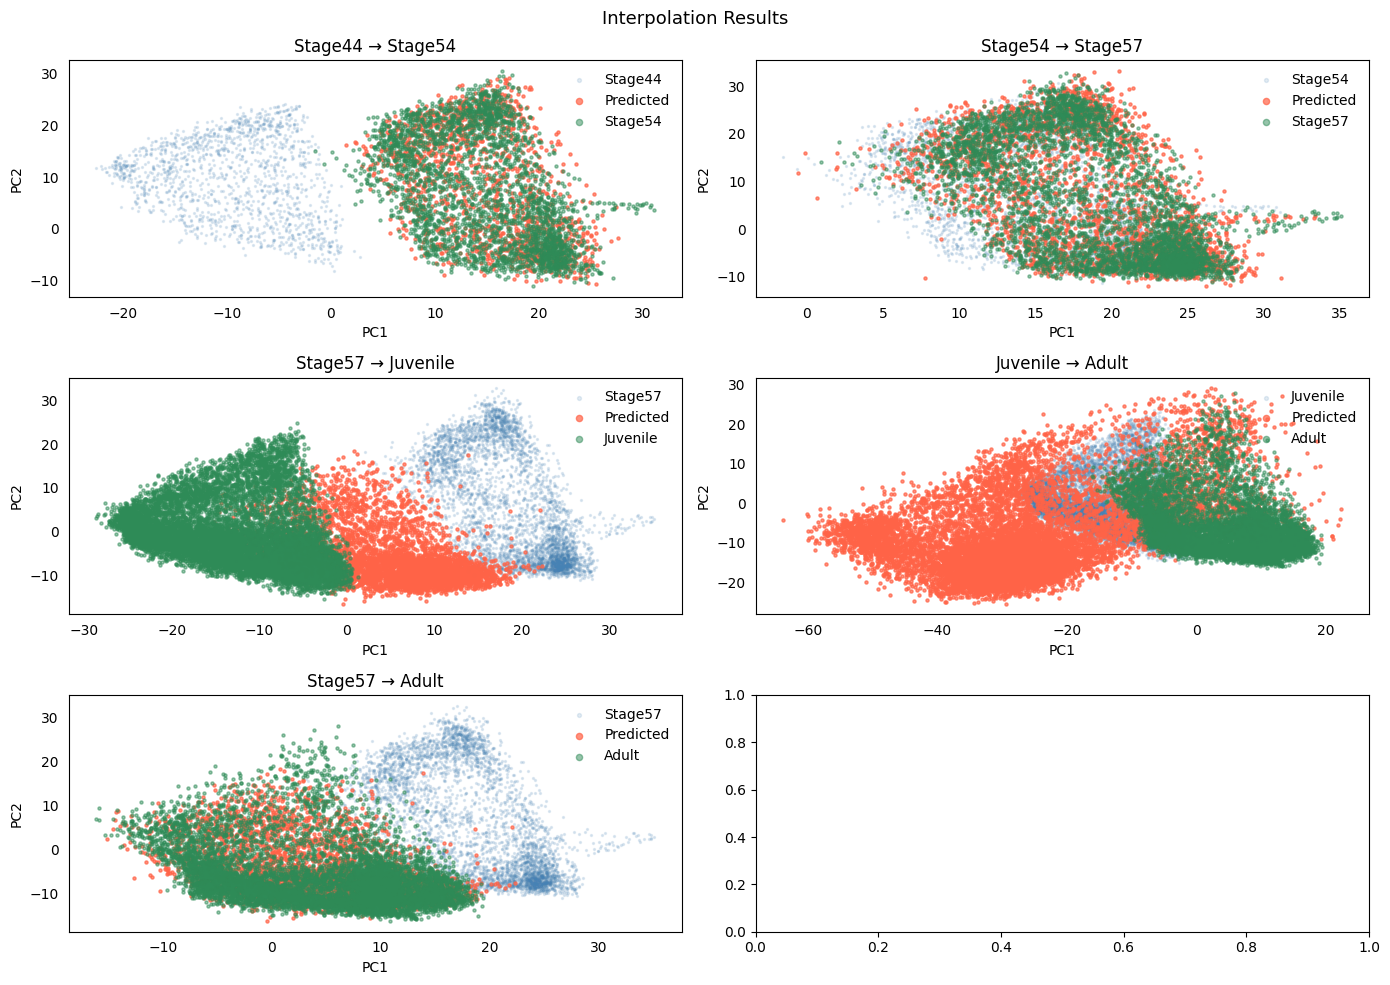

In [26]:
transitions = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
    ("Stage57", "Adult"),  # direct transition skipping Juvenile
]

preds_inter = {}
for src, tgt in transitions:
    result = model_inter.predict(
        adata,
        sort=True,
        matched_keys={(src,): (tgt,)},
        return_trajectory=True,
        num_steps=400,
    )
    preds_inter[(src, tgt)] = np.array(result.X)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, (src, tgt) in zip(axes.flat, transitions, strict=False):
    plot_transition(ax, adata, src, tgt, preds_inter[(src, tgt)])

plt.suptitle("Interpolation Results", fontsize=13)
plt.tight_layout()
plt.show()

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.90s/it]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Predicting: 100%|██████████| 1/1 [00:03<00:00,  3.82s/it]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str

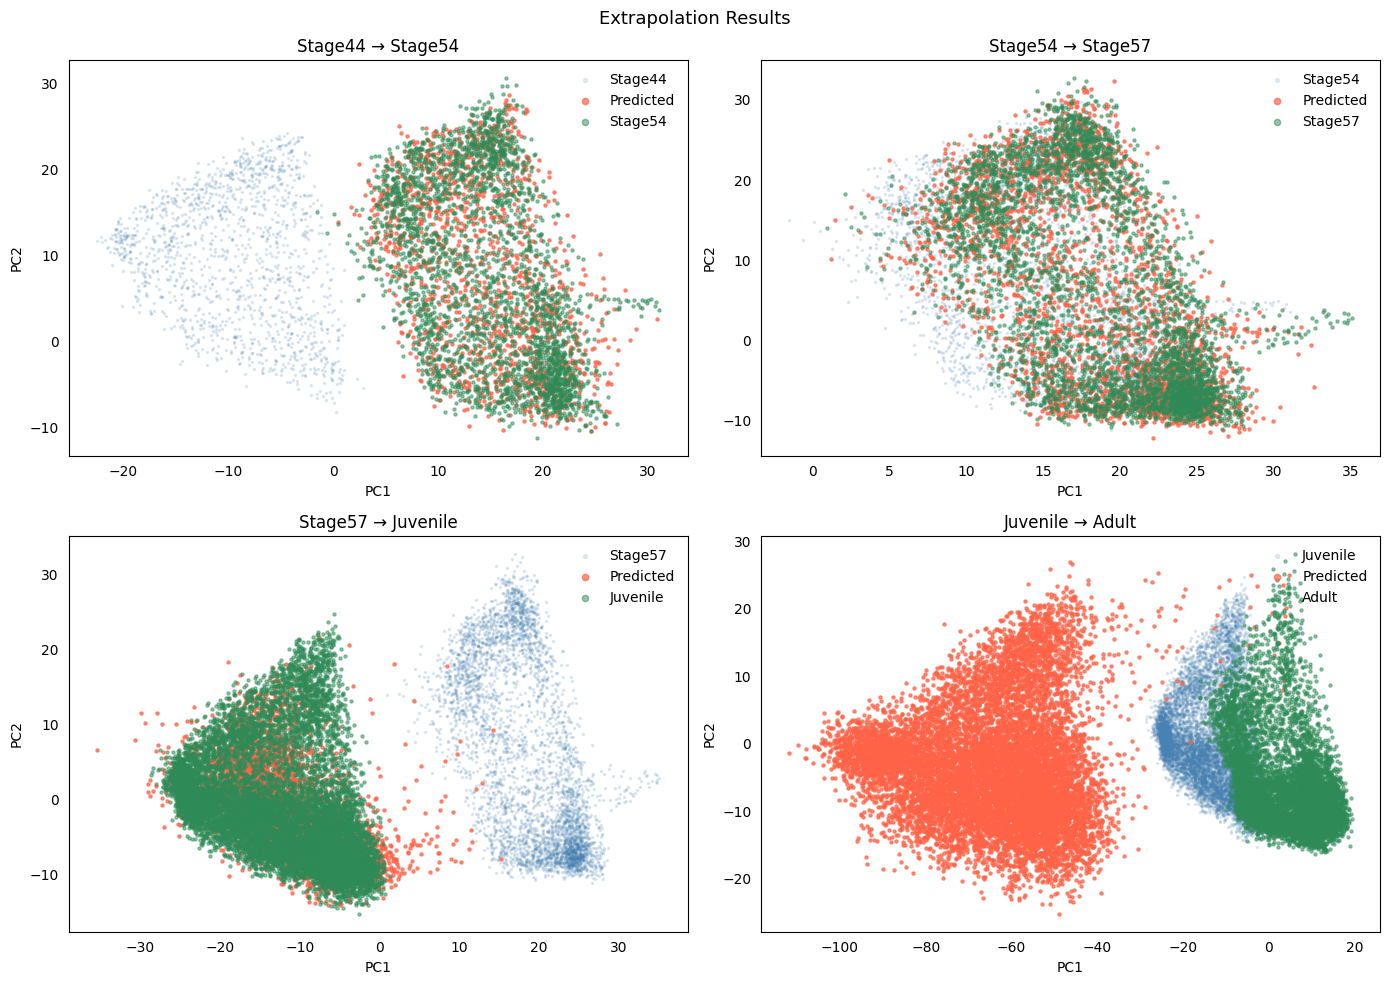

In [27]:
transitions = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
]

preds_extra = {}
for src, tgt in transitions:
    result = model_extra.predict(
        adata,
        sort=True,
        matched_keys={(src,): (tgt,)},
        return_trajectory=True,
        num_steps=400,
    )
    preds_extra[(src, tgt)] = np.array(result.X)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (src, tgt) in zip(axes.flat, transitions, strict=False):
    plot_transition(ax, adata, src, tgt, preds_extra[(src, tgt)])

plt.suptitle("Extrapolation Results", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from sc_flow.backends.torch.metrics import EnergyDistance, MaximumMeanDiscrepancy

N_EVAL = 500


def compute_w2(X, Y):
    """2-Wasserstein distance (exact EMD, subsampled to N_EVAL)."""
    rng = np.random.RandomState(SEED)
    Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)].astype(np.float64)
    Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)].astype(np.float64)
    a, b = pot.unif(Xi.shape[0]), pot.unif(Yi.shape[0])
    M = torch.cdist(torch.tensor(Xi).float(), torch.tensor(Yi).float()).numpy().astype(np.float64) ** 2
    return float(np.sqrt(pot.emd2(a, b, M)))


def compute_mmd(X, Y):
    """Multi-gamma MMD (MaximumMeanDiscrepancy, subsampled to N_EVAL)."""
    rng = np.random.RandomState(SEED)
    Xi = torch.tensor(X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]).float()
    Yi = torch.tensor(Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]).float()
    m = MaximumMeanDiscrepancy()
    m.update(Xi, Yi)
    return float(m.compute())


def compute_energy(X, Y):
    """Energy distance (EnergyDistance, subsampled to N_EVAL)."""
    rng = np.random.RandomState(SEED)
    Xi = torch.tensor(X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]).float()
    Yi = torch.tensor(Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]).float()
    m = EnergyDistance()
    m.update(Xi, Yi)
    return float(m.compute())

In [ ]:
import pandas as pd

transitions_eval = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
]


def build_metrics_rows(preds_dict, method_name):
    """Compute W2/MMD/Energy for predicted and baseline vs true target, for all transitions."""
    rows = []
    for src, tgt in transitions_eval:
        X_pred = preds_dict[(src, tgt)]
        X_src = adata[adata.obs["day"] == src].obsm["X_pca"].astype(np.float32)
        X_tgt = adata[adata.obs["day"] == tgt].obsm["X_pca"].astype(np.float32)
        label = f"{src.replace('Stage', 'S')}→{tgt.replace('Stage', 'S')}"
        rows.append(
            {
                "transition": label,
                "method": "Baseline",
                "W2": compute_w2(X_src, X_tgt),
                "MMD": compute_mmd(X_src, X_tgt),
                "Energy": compute_energy(X_src, X_tgt),
            }
        )
        rows.append(
            {
                "transition": label,
                "method": method_name,
                "W2": compute_w2(X_pred, X_tgt),
                "MMD": compute_mmd(X_pred, X_tgt),
                "Energy": compute_energy(X_pred, X_tgt),
            }
        )
    return rows


df_inter = pd.DataFrame(build_metrics_rows(preds_inter, "CTF-H"))
df_extra = pd.DataFrame(build_metrics_rows(preds_extra, "CTF-H"))

print("=== Interpolation model ===")
print(df_inter.pivot(index="transition", columns="method", values=["W2", "MMD", "Energy"]).round(4).to_string())
print()
print("=== Extrapolation model ===")
print(df_extra.pivot(index="transition", columns="method", values=["W2", "MMD", "Energy"]).round(4).to_string())

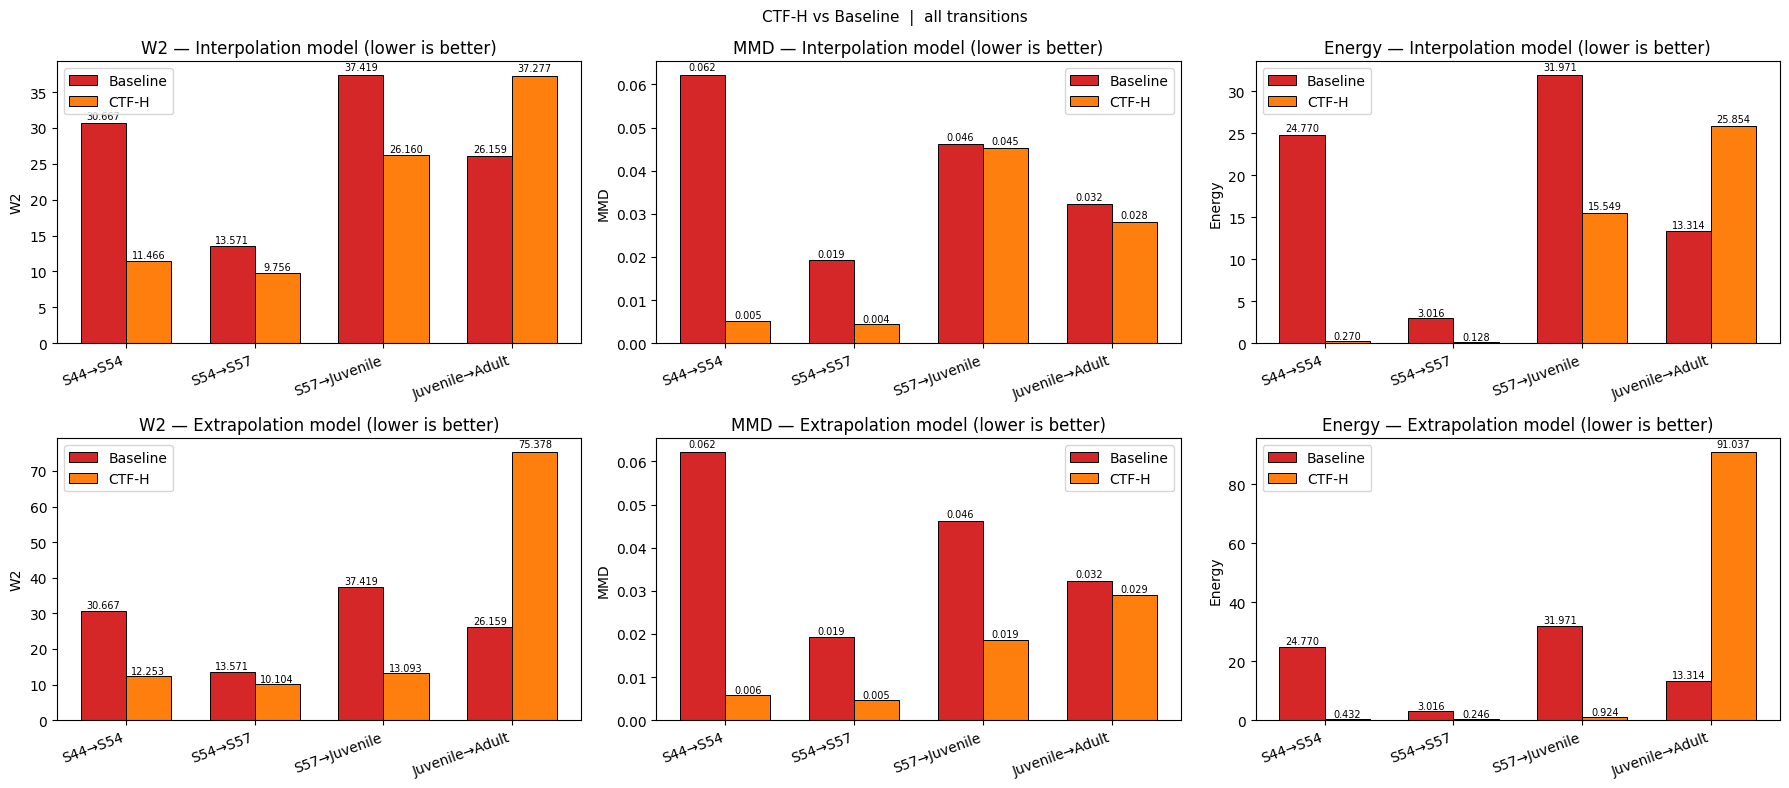

In [30]:
metric_names = ["W2", "MMD", "Energy"]
t_labels = [f"{s.replace('Stage', 'S')}→{t.replace('Stage', 'S')}" for s, t in transitions_eval]
methods = ["Baseline", "CTF-H"]
colors = {"Baseline": "#d62728", "CTF-H": "#ff7f0e"}

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
x = np.arange(len(t_labels))
w = 0.35

for row_idx, (df, model_label) in enumerate([(df_inter, "Interpolation model"), (df_extra, "Extrapolation model")]):
    for col_idx, mname in enumerate(metric_names):
        ax = axes[row_idx, col_idx]
        for i, method in enumerate(methods):
            vals = [df[(df["transition"] == t) & (df["method"] == method)][mname].values[0] for t in t_labels]
            bars = ax.bar(
                x + (i - 0.5) * w, vals, w, label=method, color=colors[method], edgecolor="black", linewidth=0.7
            )
            for bar, v in zip(bars, vals, strict=False):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f"{v:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )
        ax.set_xticks(x)
        ax.set_xticklabels(t_labels, rotation=20, ha="right")
        ax.set_title(f"{mname} — {model_label} (lower is better)")
        ax.set_ylabel(mname)
        ax.legend()

plt.suptitle("CTF-H vs Baseline  |  all transitions", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Alternative: CTF-H via `cost_fn`

The `ctf_h_coupling` above owns the full pipeline. But the effective-cost trick reduces to returning a single matrix — you can pass it directly to `ot_linear_coupling` via `cost_fn`:

```python
def c_eff_cost_fn(src, tgt, eps=0.1, lam=1.0):
    # split src/tgt, build C and M_hat identically to ctf_h_coupling
    return C - eps * torch.log(M_hat + 1e-300)  # C_eff

match_fn = functools.partial(
    ot_linear_coupling,
    cost_fn=functools.partial(c_eff_cost_fn, eps=CTF_H_EPS, lam=CTF_H_LAMBDA),
    scale_cost=1.0,   # must be 1.0 so ot_linear_coupling doesn’t rescale C_eff
    method="sinkhorn",
    reg=CTF_H_EPS,
)
model = SCFlow(method_id="cfm", backend="torch", match_fn=match_fn, ...)
```

Both approaches produce equivalent transport plans.